In [334]:
import pandas as pd
import re
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dropout, Dense,Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.optimizers import Adam

In [224]:
train_data = pd.read_csv("../data/twitter_training.csv")

In [386]:
train_data.shape

(69768, 2)

In [387]:
train_data.head()

,Sentiment,Tweet
0,Positive,i am coming to the borders and i will kill you...
1,Positive,im getting on borderlands and i will kill you all
2,Positive,im coming on borderlands and i will murder you...
3,Positive,im getting on borderlands and i will murder yo...
4,Positive,im getting into borderlands and i can murder y...


In [388]:
train_data['Sentiment'].value_counts()

Sentiment
Negative      21237
Positive      19137
Neutral       17110
Irrelevant    12284
Name: count, dtype: int64

Remove Unnecessay Column

In [226]:
train_data.drop(columns=['2401','Borderlands'],inplace=True)
train_data.head()


,Positive,"im getting on borderlands and i will murder you all ,"
0,Positive,I am coming to the borders and I will kill you...
1,Positive,im getting on borderlands and i will kill you ...
2,Positive,im coming on borderlands and i will murder you...
3,Positive,im getting on borderlands 2 and i will murder ...
4,Positive,im getting into borderlands and i can murder y...


Change the Column names

In [227]:
train_data = train_data.rename(columns={'Positive':'Sentiment','im getting on borderlands and i will murder you all ,':'Tweet'})

In [228]:
validate_data = validate_data.rename(columns={'Irrelevant':'Sentiment','I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his grandma, who now thinks I’m a lazy, terrible person 🤣':'Tweet'})

Check Informations:
numbers of Rows
Column names
data types
null values
duplicate values

In [229]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentiment  74681 non-null  object
 1   Tweet      73995 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB


In [230]:
train_data.isnull().sum()

Sentiment      0
Tweet        686
dtype: int64

In [231]:
train_data.duplicated().sum()

np.int64(4909)

In [232]:
train_data=train_data.drop_duplicates()

In [233]:
train_data["Sentiment"].value_counts()

Sentiment
Negative      21238
Positive      19138
Neutral       17111
Irrelevant    12285
Name: count, dtype: int64

In [234]:
train_data.shape

(69772, 2)

In [235]:
train_data[train_data['Tweet'].isnull()]

,Sentiment,Tweet
60,Neutral,NaN
744,Positive,NaN
2294,Irrelevant,NaN
2412,Negative,NaN


In [236]:
train_data = train_data.dropna(subset=['Tweet'])

In [237]:
train_data['Sentiment'].value_counts(normalize=True)*100

Sentiment
Negative      30.439456
Positive      27.429481
Neutral       24.524137
Irrelevant    17.606926
Name: proportion, dtype: float64

Text Cleaning:
Lowercase, Remove URLs, Remove @mentions, Remove special characters, remove extra spaces, clean tweet

In [238]:
train_data.head()

,Sentiment,Tweet
0,Positive,I am coming to the borders and I will kill you...
1,Positive,im getting on borderlands and i will kill you ...
2,Positive,im coming on borderlands and i will murder you...
3,Positive,im getting on borderlands 2 and i will murder ...
4,Positive,im getting into borderlands and i can murder y...


In [239]:
def clean_txt(txt):
    # Convert to lowerCase
    txt = txt.lower()
    # Remove URLs
    txt = re.sub(r'http\S+|www\S+', '', txt)

    # Remove @mentions
    txt = re.sub(r'@\w+', '', txt)

    # Remove special characters and numbers
    txt = re.sub(r'[^a-zA-Z\s]', '', txt)

    # Remove extra spaces
    txt = re.sub(r'\s+', ' ', txt).strip()
    return txt

In [240]:
train_data['Tweet'] = train_data['Tweet'].apply(clean_txt)

In [241]:
train_data['Tweet'].sample(10)

25365    such a honest general admission thanks for dee...
42450                           wonderful decision made by
66660    alas the same people who make your baby powder...
56882    i only been getting duplicate lately whats goi...
68236    stop sending death messages to developers ya p...
46273    thank you for helping small businesses the vit...
25313    google maps is interesting and nostalgic i was...
58758    this is the time of year when i ask facebook t...
15283                             a very interesting video
6301             everything about this book sounds so good
Name: Tweet, dtype: object

Train Test Split

In [242]:
X = train_data['Tweet']
Y = train_data['Sentiment']

In [243]:
Y.value_counts()

Sentiment
Negative      21237
Positive      19137
Neutral       17110
Irrelevant    12284
Name: count, dtype: int64

In [244]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [290]:
X_train.shape

(55814,)

In [245]:
label_encode=LabelEncoder()

In [246]:
y_train_encoder = label_encode.fit_transform(y_train)

In [247]:
y_test_encoder = label_encode.transform(y_test)

In [248]:
print(y_train_encoder[:10])

[1 1 3 2 1 3 0 3 3 3]


Tokenizer: A Tokenizer is a tool that splits raw text into smaller units called tokens (usually words) and converts each token into a unique integer, so a machine learning model can process it.
The Keras Tokenizer class does two jobs: Builds a vocabulary and Encodes text

In [349]:
tokenizer = Tokenizer(
    num_words=20000,
    oov_token="<OOV>"
)

In [350]:
tokenizer.fit_on_texts(X_train)

In [351]:
X_train_seq = tokenizer.texts_to_sequences(X_train)

In [352]:
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [372]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=70,
    padding="post",
    truncating="post"
)

In [373]:
X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=70,
    padding="post",
    truncating="post"
)

In [355]:
print("X_train_seq:", len(X_train_seq))
print("X_test_seq:", len(X_test_seq))

print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)

X_train_seq: 55814
X_test_seq: 13954
X_train_pad shape: (55814, 75)
X_test_pad shape: (13954, 75)


Embedding: An embedding converts word IDs into learnable vectors that capture meaning.
and RNN

In [374]:
model = Sequential([
    Input(shape=(70,)),
    Embedding(
        input_dim=20000,
        output_dim=128
    ),

    SimpleRNN(64, dropout=0.2),  
    Dropout(0.5),

    Dense(4, activation="softmax")
])

In [376]:
model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_17 (Embedding)        │ (None, 70, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_18 (SimpleRNN)       │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,572,612 (9.81 MB)

 Trainable params: 2,572,612 (9.81 MB)

 Non-trainable params: 0 (0.00 B)

In [377]:
model.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [378]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [379]:
history = model.fit(
    X_train_pad,
    y_train_encoder,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/15
785/785 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.3913 - loss: 1.2953 - val_accuracy: 0.5650 - val_loss: 1.0800
Epoch 2/15
785/785 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.6638 - loss: 0.8795 - val_accuracy: 0.6895 - val_loss: 0.8273
Epoch 3/15
785/785 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.7960 - loss: 0.5847 - val_accuracy: 0.7513 - val_loss: 0.6815
Epoch 4/15
785/785 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8552 - loss: 0.4282 - val_accuracy: 0.7762 - val_loss: 0.6316
Epoch 5/15
785/785 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8877 - loss: 0.3397 - val_accuracy: 0.7875 - val_loss: 0.6240
Epoch 6/15
785/785 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9082 - loss: 0.2793 - val_accuracy: 0.7793 - val_loss: 0.6648
Epoch 7/15
785/785 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9220 - loss: 0.2370 - val_accuracy: 0.7929 - val_loss: 0.6493


In [380]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test_encoder
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7925 - loss: 0.6294
Test Loss: 0.6293511390686035
Test Accuracy: 0.7925326228141785


In [381]:
y_pred_prob = model.predict(X_test_pad)

437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [382]:
y_pred = np.argmax(y_pred_prob, axis=1)
final_accuracy = accuracy_score(y_test_encoder, y_pred)
print(final_accuracy)

0.7925326071377383


In [385]:
print(history.history)

{'accuracy': [0.3913043439388275, 0.6638397574424744, 0.7960065007209778, 0.8551918864250183, 0.8876811861991882, 0.9082457423210144, 0.9220018982887268], 'loss': [1.2952648401260376, 0.8795490264892578, 0.5847095847129822, 0.4282101094722748, 0.33971548080444336, 0.2793278694152832, 0.2369978129863739], 'val_accuracy': [0.5650304555892944, 0.6895378232002258, 0.7513436079025269, 0.7762450575828552, 0.7875313758850098, 0.7792905569076538, 0.7929057478904724], 'val_loss': [1.0800355672836304, 0.8273144364356995, 0.6814741492271423, 0.6316031813621521, 0.6240494251251221, 0.6647744178771973, 0.6492552757263184]}


{'accuracy': [0.3913043439388275, 0.6638397574424744, 0.7960065007209778, 0.8551918864250183, 0.8876811861991882, 0.9082457423210144, 0.9220018982887268], 
'loss': [1.2952648401260376, 0.8795490264892578, 0.5847095847129822, 0.4282101094722748, 0.33971548080444336, 0.2793278694152832, 0.2369978129863739], 
'val_accuracy': [0.5650304555892944, 0.6895378232002258, 0.7513436079025269, 0.7762450575828552, 0.7875313758850098, 0.7792905569076538, 0.7929057478904724], 
'val_loss': [1.0800355672836304, 0.8273144364356995, 0.6814741492271423, 0.6316031813621521, 0.6240494251251221, 0.6647744178771973, 0.6492552757263184]}

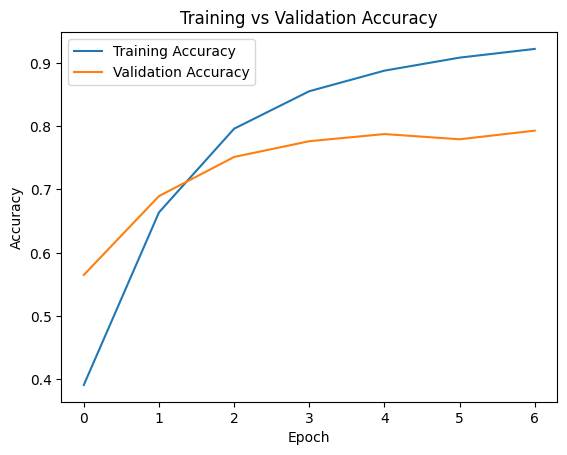

In [384]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [383]:
import numpy as np

y_pred = np.argmax(y_pred_prob, axis=1)

print(
    classification_report(
        y_test_encoder,
        y_pred,
        target_names=label_encode.classes_
    )
)

              precision    recall  f1-score   support

  Irrelevant       0.78      0.65      0.70      2457
    Negative       0.78      0.89      0.83      4248
     Neutral       0.82      0.75      0.78      3422
    Positive       0.80      0.82      0.81      3827

    accuracy                           0.79     13954
   macro avg       0.79      0.78      0.78     13954
weighted avg       0.79      0.79      0.79     13954



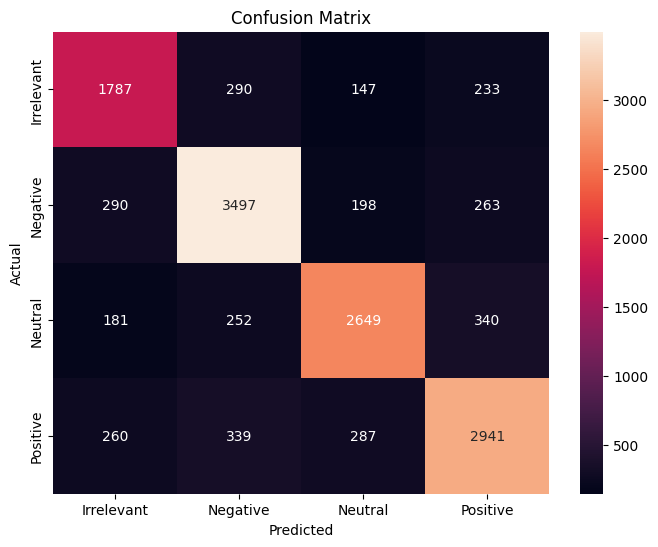

In [345]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test_encoder,
    y_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encode.classes_,
    yticklabels=label_encode.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Save the trained model

In [347]:
model.save("../model/sentiment_model.keras")

In [348]:
from tensorflow.keras.models import load_model
import pickle

loaded_model = load_model(
    "../model/sentiment_model.keras"
)

with open("../model/tokenizer.pkl", "rb") as file:
    loaded_tokenizer = pickle.load(file)

with open("../model/label_encode.pkl", "rb") as file:
    loaded_label_encode = pickle.load(file)

print("Model loaded successfully!")
print("Tokenizer loaded successfully!")
print("Label encoder loaded successfully!")

Model loaded successfully!
Tokenizer loaded successfully!
Label encoder loaded successfully!
